# 01_01 — Burn-Occurrence Model (calibrated probability)

**Goal:** Predict the monthly probability that a 4 km cell burns at all
(`IS_FIRE = burned_area_km2 > 0`) — Stage 1 of the two-stage burned-area
hurdle. The product is a **calibrated burn probability**; no classification
threshold is applied.

**Split:** train on water years 2001–2020, hold out **WY 2021–2024** for
evaluation. Single fit, no walk-forward, no window sweep.

| | |
|---|---|
| **Input**  | `model_data_burned_area_4km.parquet` (from 01_00) |
| **Label**  | `IS_FIRE = burned_area_km2 > 0` |
| **Output** | calibrated burn-probability parquet (2021–2024), per-year metrics CSV, PR / reliability / histogram PNG |


## Model structure

**Role.** Stage 1 of a two-stage (hurdle) burned-area model: a binary classifier
for monthly burn occurrence. Stage 2 (regressor for `log_burned_area` on fire
cells only) is trained separately; the two are combined downstream. Because
occurrence covers both ignition *and* fire spread into a cell, this model leans
on antecedent / neighbourhood fuel signals (`convLAI_mean6m`, `burned_prev_wy`,
multi-month dryness) as well as concurrent fire weather.

**Learner.** Gradient-boosted decision trees (`XGBClassifier`,
`tree_method="hist"`, logistic objective) predicting P(burn). One fixed
hyperparameter configuration, no tuning. Settings: 600 trees, depth 6,
learning rate 0.05, row/column subsampling 0.8, `min_child_weight` 5, L2 = 1.

**Class imbalance.** Positive (burn) rate ≈0.31 % (≈1:323). Because the product
is a *calibrated probability* never thresholded, class weighting is left **off**
by default (`USE_CLASS_WEIGHT = False`): up-weighting deliberately inflates
predicted probabilities to favour recall, forcing the calibrator to undo it,
and tends to mis-scale the result. The logistic objective is a proper scoring
rule and already targets P(burn | x) at the natural prevalence. (Flip to
`True` for a recall-oriented classifier.)

**Probability calibration.** Within the training data the classifier is fit on
one slice and a prefit `CalibratedClassifierCV` (Platt/sigmoid) is fitted on a
held-out slice. `CALIB_MODE` controls the split:
`"stratified_frac"` uses a random `CALIB_FRAC` (10 %) stratified hold-out across
all training years (default; mixes prevalences); `"recent_years"` uses the **last
`CALIB_RECENT_N` training water years** as the calibration set — closer in
prevalence to the held-out test period under non-stationarity (recent California
fire trends upward). Calibrating against a single year is risky if that year is
anomalous (WY 2020 was a mega-fire year), so the default is `CALIB_RECENT_N = 2` (WY 2019 + 2020). `CALIB_METHOD` is
`isotonic` by default — more flexible at the upper tail than sigmoid, which matters
for spreading the high-probability bins after auto-context (sigmoid was used in the
ignition paper but compresses the tail here, where the autocontext model produces a
wider predicted-probability range). The model output is the **calibrated burn
probability** — saved and evaluated as-is; no threshold.

**Temporal split.** Train on water years 2001–2020 (Oct 2000 – Sep 2020),
predict on **water years 2021–2024** (Oct 2020 – Sep 2024). Evaluated per year
and pooled across the 4-year block. No information from 2021–2024 enters
training or calibration. *Caveat:* recent California fire seasons trend more
extreme than the historical average, so a model calibrated on 2001–2020 may
*under-predict* fire-rich test years (a non-stationarity / prevalence-shift
effect) — visible as the reliability curve sitting above the diagonal.

**Features.** Auto-collected from the combined table — everything except IDs
and targets: gridMET monthly means, anomalies, long-term climatology and
antecedent windows; vegetation one-hot + `burn_freq`; LAI features (`LAI_mean6m`,
`convLAI_mean6m`); population, road, power, slope; EPA Level III ecoregion
one-hot; `burned_prev_wy`. All antecedent or concurrent drivers; the
burned-area target is never used as a predictor.

**Auto-context features.** Two additional features encode the *predicted fire
probability of the cell's spatial neighbors* for the same month: `nbr_pred_mean3`
(mean over the 8 surrounding 4 km cells) and `nbr_pred_p90` (90th-percentile across the 8). They are
produced in two passes — a *base* XGBoost (standard features only) is fit via
5-fold **year-blocked** cross-validation to produce leakage-free OOF predictions
for training cell-months, and a final base model fit on all training data
produces test predictions; neighbor mean/max are then computed per month on the
4 km grid via queen-contiguity convolution. The *autocontext* XGBoost is fit on
the standard features **plus** these two neighbor features. This addresses the
spatial-cluster structure of fire-perimeter occurrence — a cell whose neighbors
are also high-risk is more likely to burn — without requiring a deep spatial
model. Year-blocked CV (groups = water years) is essential: cells within a fire
perimeter share a water year, so year-grouping prevents the base from seeing a
cell's target while predicting its neighbor's, which would bias the auto-context
features. (Note: this OOF construction is not strictly temporally causal — the
base for early-year predictions sees later years — but it preserves cell-to-cell
independence within a year, which is the relevant leakage axis here.)

**Hierarchical aggregate constraint (Stage 2c).** Independently of the cell-level
autocontext model, a small Poisson regression is fitted on **monthly statewide**
burned cell-month count using statewide-averaged drought (SPEI 30/90/180/270 d) and
fire-weather (VPD, ERC, max temperature, min RH, fm1000) features plus seasonal
sinusoids (`mo_sin`, `mo_cos`). At inference, cell-level probabilities for each test
month are **rescaled in logit space** — `p_new = σ(logit(p) + s)`, where the additive
shift `s` is solved per month so that Σ_cells p_new equals the monthly Poisson
prediction. This preserves the within-month spatial ranking exactly while enforcing
aggregate-count consistency across months. Targets the failure mode visible in the
time series: the cell model gets the *spatial pattern* of fire-prone months roughly
right but cannot distinguish a high-fire summer (2021, 2024) from a low-fire summer
(2023) because the year-to-year discriminating signal is a regional drought / climate
story that lives at the aggregate scale, not the cell scale.

**Metrics.** At a ~0.3 % base rate, headline skill is **PR-AUC** (with lift
over the base rate). Diagnostics include the **ROC** curve (rank-based skill),
the **PR-Gain** curve (Flach & Kull 2015, which fixes the imbalance bias of
standard PR), the **reliability** curve (log-spaced bins on log-log axes for a
rare event), the **predicted-probability distribution**, a **monthly time
series** of observed-vs-predicted burned cell-months across the test period
(an aggregate calibration check), and **Brier**. Reported per year and pooled.


## Config

In [1]:
# ── Config ────────────────────────────────────────────────────
import os, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.optimize import brentq
from scipy.special import expit, logit
from scipy.stats import pearsonr
from numpy.lib.stride_tricks import sliding_window_view
import warnings
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, precision_recall_curve,
                             roc_curve)

PROC_DIR  = r"E:\Data2_14TB\zcao\Burned_Area\processed"
MODEL_DIR = r"E:\Data2_14TB\zcao\Burned_Area\models"
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = os.path.join(PROC_DIR, "model_data_burned_area_4km.parquet")
RUN_TAG   = "occ_ac_iso_hier"

# ── Temporal split ────────────────────────────────────────────
TRAIN_START_WY = 2001
TRAIN_END_WY   = 2020
TEST_START_WY  = TRAIN_END_WY + 1    # 2021
TEST_END_WY    = 2024

# Columns that are NOT features
ID_COLS     = ["lon", "lat", "year", "month", "water_year", "ecoregion"]
TARGET_COLS = ["log_burned_area", "burned_area_km2", "cell_area_km2"]

# ── Calibration (10/90 stratified split — ignition convention) ─
CALIB_FRAC   = 0.10
CALIB_METHOD = "isotonic"           # try "isotonic" if sigmoid under-fits
RANDOM_STATE = 315

# CALIB_MODE controls which slice of the training data is used for the
# prefit calibration.
#   "stratified_frac"  : random CALIB_FRAC stratified holdout across all
#                        training years (default; mixes prevalences).
#   "recent_years"     : use the LAST CALIB_RECENT_N water years as the
#                        calibration set — closer in prevalence to the
#                        held-out test years. WY 2020 was a mega year, so
#                        calibrating on 2020 alone would over-correct;
#                        a 2-3 year window (e.g. 2019+2020) is safer.
CALIB_MODE      = "recent_years"   # "stratified_frac" | "recent_years"
CALIB_RECENT_N  = 2                   # # of trailing training WYs if "recent_years"

# Class weighting OFF by default: output is a calibrated probability that is
# never thresholded; up-weighting positives would inflate probabilities and
# harm calibration. Logistic loss already targets P(burn|x) at the natural
# prevalence. Set True for a recall-oriented classifier.
USE_CLASS_WEIGHT = False

# Auto-context: K-fold YEAR-BLOCKED CV produces clean OOF base predictions
# on training data, used to compute spatial-neighbor features for the
# autocontext model. 5 folds × 4 years = full 20-year training coverage.
AUTO_CONTEXT_KFOLDS = 5

# Hierarchical aggregate constraint (Stage 2c): fit a monthly statewide
# burned-count predictor on drought + seasonal features, then rescale
# cell-level probabilities (logit-shift) so they sum to the predicted
# monthly total. Targets the year-to-year peak misses (2023 over,
# 2021/2024 under) that cell-only modeling cannot solve.
HIERARCHICAL_RESCALE = True
MONTHLY_MODEL  = "poisson"     # "poisson" | "xgb_poisson"
                                 # poisson = linear (interpretable, low-variance);
                                 # xgb_poisson = tree-based with count:poisson loss
                                 # (captures regime interactions, more variance).
BLEND_ALPHA    = 0.0             # 0..1: final = α·orig + (1−α)·rescaled.
BLEND_ALPHA_SWEEP = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]   # Pareto-frontier scan in Stage 2d
                                 # 0   = full hierarchical rescale (current behavior)
                                 # 1   = autocontext only (no rescale)
                                 # 0.3 = retain 30%% of cell-level autocontext signal,
                                 #       trading some monthly-shape skill for pooled-
                                 #       ranking precision (AUPRG).

# ── XGBoost — single fixed config; no tuning ──────────────────
XGB_PARAMS = dict(
    n_estimators     = 600,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_lambda       = 1.0,
    tree_method      = "hist",
    eval_metric      = "aucpr",
    n_jobs           = -1,
    random_state     = RANDOM_STATE,
)

print(f"Data       : {DATA_PATH}")
print(f"Train WY   : {TRAIN_START_WY} – {TRAIN_END_WY}  "
      f"({TRAIN_END_WY - TRAIN_START_WY + 1} years)")
print(f"Test WY    : {TEST_START_WY} – {TEST_END_WY}  "
      f"({TEST_END_WY - TEST_START_WY + 1} years held out)")
print(f"Calibrate  : {CALIB_METHOD}, {int(CALIB_FRAC*100)}% holdout")
print(f"Class wt   : {USE_CLASS_WEIGHT}")


Data       : E:\Data2_14TB\zcao\Burned_Area\processed\model_data_burned_area_4km.parquet
Train WY   : 2001 – 2020  (20 years)
Test WY    : 2021 – 2024  (4 years held out)
Calibrate  : isotonic, 10% holdout
Class wt   : False


---
## Diagnostic helpers (shared)


In [2]:
# ── Diagnostic helpers (shared across Stages 2d, 4, 4b) ──────────
# Defined here, near the top, so any cell that uses them (notably the
# Stage 2d blend sweep, which runs before Stage 4) has them in scope.
# Reliability uses LOG-SPACED bin edges across the predicted-probability
# range (not quantile bins, which crowd into the bulk on heavy-tailed
# distributions). PR-Gain uses the Flach & Kull (2015) framework, which
# fixes the imbalance bias in the standard PR curve.

def log_reliability(y_true, y_prob, n_bins=12, min_count=50):
    """Log-spaced reliability bins. Returns (mean_pred, frac_pos, n, edges)."""
    lo = max(y_prob.min(), 1e-6)
    hi = max(y_prob.max(), lo * 10)
    edges = np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
    mp, fp, nb = [], [], []
    for k in range(n_bins):
        if k < n_bins - 1:
            m = (y_prob >= edges[k]) & (y_prob < edges[k + 1])
        else:
            m = (y_prob >= edges[k]) & (y_prob <= edges[k + 1])
        if m.sum() < min_count:
            continue
        mp.append(y_prob[m].mean()); fp.append(y_true[m].mean())
        nb.append(int(m.sum()))
    return np.array(mp), np.array(fp), np.array(nb), edges


def precision_recall_gain(y_true, y_prob, eps=1e-12):
    """PR-Gain curve per Flach & Kull (2015, NeurIPS).

    Returns (recall_gain, precision_gain) sorted by descending score
    (i.e. recall_gain ascending). pg is NOT clipped — it can be negative
    (curve below the no-skill baseline). Leading rows before the first
    true positive are dropped (precision undefined there).

    This rewrites the earlier helper which (i) was fed sklearn's
    `precision_recall_curve` output and (ii) filtered points where
    gain < 0 rather than including their signed contribution. Both
    underestimate AUPRG and are hyper-sensitive to where the curve
    crosses zero — exactly what changed under the hierarchical rescale.

    For an external cross-check, the reference implementation is at
    https://github.com/meeliskull/prg (Python package: `pyprg`).
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    pi = y_true.mean()
    if pi == 0 or pi == 1:
        return np.array([0.0, 1.0]), np.array([1.0, 1.0])

    order = np.argsort(-y_prob, kind="mergesort")
    y_true_s = y_true[order]

    # Drop the leading run of non-positives before the first TP — precision
    # is undefined / spurious there (0/k → ∞ in PG space).
    first_tp = int(np.argmax(y_true_s == 1))
    TP = np.cumsum(y_true_s)[first_tp:]
    FP = np.cumsum(1 - y_true_s)[first_tp:]
    P  = int(y_true_s.sum())

    with np.errstate(divide="ignore", invalid="ignore"):
        prec = TP / (TP + FP)
        rec  = TP / P
        # Flach & Kull (2015) eq. 5
        pg = 1.0 - (pi / (1 - pi)) * ((1 - prec) / np.maximum(prec, eps))
        rg = 1.0 - (pi / (1 - pi)) * ((1 - rec)  / np.maximum(rec,  eps))

    # Prepend the (rg=0, pg=1) starting anchor — first TP, highest threshold.
    rg = np.concatenate([[0.0], rg])
    pg = np.concatenate([[1.0], pg])
    return rg, pg


def auprg(rg, pg):
    """Area under PR-Gain curve over rg ∈ [0, 1], signed pg."""
    order = np.argsort(rg, kind="mergesort")
    rg, pg = rg[order], pg[order]
    mask = (rg >= 0) & (rg <= 1) & np.isfinite(rg) & np.isfinite(pg)
    if mask.sum() < 2:
        return 0.0
    return float(np.trapz(pg[mask], rg[mask]))


---
## Stage 1 — Load data & build occurrence label

In [3]:
# ── 1.1  Load, build label, assemble design matrix ────────────
df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {df.shape}")

df["IS_FIRE"] = (df["burned_area_km2"] > 0).astype("int8")

feature_cols = [c for c in df.columns
                if c not in ID_COLS + TARGET_COLS + ["IS_FIRE"]]

base_all = df["IS_FIRE"].mean()
print(f"\nFeatures ({len(feature_cols)}):\n  {feature_cols}")
print(f"\nLabel balance: {int(df['IS_FIRE'].sum()):,} fire / {len(df):,} "
      f"cell-months  (base rate {base_all*100:.4f}%)")

X   = df[feature_cols].astype("float32")
y   = df["IS_FIRE"].to_numpy()
wy  = df["water_year"].to_numpy()
ids = df[["lon", "lat", "year", "month", "water_year"]].copy()
del df; gc.collect()
print(f"\nX: {X.shape}  ({X.memory_usage(deep=True).sum()/1e9:.2f} GB, float32)")


Loaded: (3657312, 87)

Features (78):
  ['LAI_mean6m', 'bi', 'burn_freq', 'burned_prev_wy', 'consec_dry_days', 'consec_hot_days', 'convLAI_mean6m', 'eco_Cascades', 'eco_Central_Basin_and_Range', 'eco_Central_California_Foothills_and_Coastal_Mountains', 'eco_Central_California_Valley', 'eco_Coast_Range', 'eco_Eastern_Cascades_Slopes_and_Foothills', 'eco_Klamath_Mountains_California_High_North_Coast_Range', 'eco_Mojave_Basin_and_Range', 'eco_Northern_Basin_and_Range', 'eco_Sierra_Nevada', 'eco_Sonoran_Basin_and_Range', 'eco_Southern_California_Mountains', 'eco_Southern_California_Northern_Baja_Coast', 'erc', 'fm100', 'fm1000', 'fm1000_avg1', 'fm1000_avg2', 'fm1000_avg3', 'fm100_avg1', 'fm100_avg2', 'fm100_avg3', 'minor_line_density', 'pole_density', 'population_density', 'pr', 'pr_anomaly', 'pr_avg1', 'pr_avg2', 'pr_avg3', 'pr_ltm_mean', 'pr_ltm_std', 'rmax', 'rmin', 'rmin_anomaly', 'road_density', 'slope_avg', 'slope_max', 'spei180d', 'spei270d', 'spei30d', 'spei30d_avg1', 'spei30d_avg2

---
## Stage 2a — Train/test split + auto-context feature engineering


In [4]:
# ── 2a.1  Train/test masks and helper ─────────────────────────
def make_calibrator(clf, method):
    """CalibratedClassifierCV(prefit) — handle estimator/base_estimator rename."""
    try:
        return CalibratedClassifierCV(estimator=clf, method=method, cv="prefit")
    except TypeError:
        return CalibratedClassifierCV(base_estimator=clf, method=method, cv="prefit")


tr = (wy >= TRAIN_START_WY) & (wy <= TRAIN_END_WY)
te = (wy >= TEST_START_WY)  & (wy <= TEST_END_WY)

Xtr, ytr = X[tr], y[tr]
Xte, yte = X[te], y[te]
print(f"Train rows : {len(ytr):,}  ({int(ytr.sum()):,} fire, "
      f"{ytr.mean()*100:.4f}% base)")
print(f"Test rows  : {len(yte):,}  ({int(yte.sum()):,} fire, "
      f"{yte.mean()*100:.4f}% base)")

# ── 2a.2  Year-blocked K-fold OOF base predictions on training ──
# Groups = water years → all cells from a given year stay in one fold,
# so the base model never sees a cell's target while predicting that
# cell's neighbor (which would leak through the spatial auto-context
# features). scale_pos_weight=1.0 for the base regardless of the
# USE_CLASS_WEIGHT toggle — we only need the base's RANKING here.
oof_base = np.zeros(len(ytr), dtype="float32")
wy_tr_groups = wy[tr]
gkf = GroupKFold(n_splits=AUTO_CONTEXT_KFOLDS)
t0 = time.time()
for k, (fit_idx, hold_idx) in enumerate(gkf.split(Xtr, ytr, groups=wy_tr_groups)):
    base_fold = XGBClassifier(**XGB_PARAMS, scale_pos_weight=1.0)
    base_fold.fit(Xtr.iloc[fit_idx], ytr[fit_idx])
    oof_base[hold_idx] = base_fold.predict_proba(Xtr.iloc[hold_idx])[:, 1]
    held = sorted(np.unique(wy_tr_groups[hold_idx]).tolist())
    print(f"  fold {k+1}/{AUTO_CONTEXT_KFOLDS}: held-out WY {held} "
          f"({len(hold_idx):,} rows)")
    del base_fold; gc.collect()
print(f"OOF base predictions done in {(time.time()-t0)/60:.1f} min")

# ── 2a.3  Final base model on full training → test predictions ──
t0 = time.time()
base_final = XGBClassifier(**XGB_PARAMS, scale_pos_weight=1.0)
base_final.fit(Xtr, ytr)
test_base_pred = base_final.predict_proba(Xte)[:, 1].astype("float32")
print(f"Final base fit + test predict in {(time.time()-t0)/60:.1f} min")

# Base-only test skill (uncalibrated; rank metrics invariant to calibration)
print(f"\nBase model on test (raw, no calibration) — baseline before auto-context:")
print(f"  PR-AUC  : {average_precision_score(yte, test_base_pred):.4f}")
print(f"  ROC-AUC : {roc_auc_score(yte, test_base_pred):.4f}")

del base_final; gc.collect()

# ── 2a.4  Neighbor MEAN and 90th-PERCENTILE of predicted probability ─
# Per (year, month): pivot the panel onto the regular 4 km lat/lon grid,
# take 3×3 sliding windows (queen contiguity, exclude center), and compute
# the nan-aware mean and 90th-percentile of the 8 neighbors.
# p90 instead of max: max is highly sensitive to a single mispredicted
# neighbor, which amplifies base-model errors through auto-context; the
# 90th-percentile keeps the spatial-cluster signal but is robust to one
# bad neighbor.
train_ids = ids[tr].copy().reset_index(drop=True)
train_ids["pred_prob"] = oof_base
test_ids  = ids[te].copy().reset_index(drop=True)
test_ids["pred_prob"]  = test_base_pred
full_panel = pd.concat([train_ids, test_ids], ignore_index=True)

all_lons = np.sort(full_panel["lon"].unique())
all_lats = np.sort(full_panel["lat"].unique())
full_panel["i_lat"] = np.searchsorted(all_lats, full_panel["lat"].values)
full_panel["j_lon"] = np.searchsorted(all_lons, full_panel["lon"].values)

nbr_mean = np.zeros(len(full_panel), dtype="float32")
nbr_p90  = np.zeros(len(full_panel), dtype="float32")

t0 = time.time()
groups = full_panel.groupby(["year", "month"], sort=False)
for (_yr, _mo), grp in groups:
    arr = np.full((len(all_lats), len(all_lons)), np.nan, dtype="float32")
    arr[grp["i_lat"].values, grp["j_lon"].values] = grp["pred_prob"].values
    padded = np.pad(arr, 1, mode="constant", constant_values=np.nan)
    windows = sliding_window_view(padded, (3, 3)).reshape(*arr.shape, 9)
    neighbors = np.delete(windows, 4, axis=-1)   # drop center → 8 values
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        nm   = np.nanmean(neighbors, axis=-1)
        np90 = np.nanpercentile(neighbors, 90, axis=-1)
    nm   = np.where(np.isnan(nm),   0.0, nm  ).astype("float32")
    np90 = np.where(np.isnan(np90), 0.0, np90).astype("float32")
    nbr_mean[grp.index.values] = nm  [grp["i_lat"].values, grp["j_lon"].values]
    nbr_p90 [grp.index.values] = np90[grp["i_lat"].values, grp["j_lon"].values]
print(f"Neighbor features computed in {(time.time()-t0)/60:.1f} min "
      f"({groups.ngroups} months)")

full_panel["nbr_pred_mean3"] = nbr_mean
full_panel["nbr_pred_p90"]   = nbr_p90

# ── 2a.5  Augment X with the two auto-context features ──────────
n_train_rows = len(train_ids)
ac_train = full_panel.iloc[:n_train_rows][["nbr_pred_mean3",
                                            "nbr_pred_p90"]].reset_index(drop=True)
ac_test  = full_panel.iloc[n_train_rows:][["nbr_pred_mean3",
                                            "nbr_pred_p90"]].reset_index(drop=True)

Xtr_ac = pd.concat([Xtr.reset_index(drop=True), ac_train.astype("float32")], axis=1)
Xte_ac = pd.concat([Xte.reset_index(drop=True),  ac_test.astype("float32")],  axis=1)

feature_cols_ac = feature_cols + ["nbr_pred_mean3", "nbr_pred_p90"]
print(f"\nAuto-context features: nbr_pred_mean3, nbr_pred_p90")
print(f"Xtr_ac shape : {Xtr_ac.shape}   Xte_ac shape : {Xte_ac.shape}")
print(f"  nbr_pred_mean3  range: "
      f"[{ac_train['nbr_pred_mean3'].min():.5f}, "
      f"{ac_train['nbr_pred_mean3'].max():.4f}]")
print(f"  nbr_pred_p90    range: "
      f"[{ac_train['nbr_pred_p90'].min():.5f}, "
      f"{ac_train['nbr_pred_p90'].max():.4f}]")

del oof_base, test_base_pred, full_panel, train_ids, test_ids, Xtr, Xte
gc.collect()


Train rows : 3,047,760  (9,039 fire, 0.2966% base)
Test rows  : 609,552  (2,258 fire, 0.3704% base)
  fold 1/5: held-out WY [2005, 2010, 2015, 2020] (609,552 rows)
  fold 2/5: held-out WY [2006, 2011, 2016, 2019] (609,552 rows)
  fold 3/5: held-out WY [2002, 2007, 2012, 2017] (609,552 rows)
  fold 4/5: held-out WY [2003, 2008, 2013, 2018] (609,552 rows)
  fold 5/5: held-out WY [2001, 2004, 2009, 2014] (609,552 rows)
OOF base predictions done in 4.6 min
Final base fit + test predict in 1.1 min

Base model on test (raw, no calibration) — baseline before auto-context:
  PR-AUC  : 0.0147
  ROC-AUC : 0.8354
Neighbor features computed in 7.8 min (288 months)

Auto-context features: nbr_pred_mean3, nbr_pred_p90
Xtr_ac shape : (3047760, 80)   Xte_ac shape : (609552, 80)
  nbr_pred_mean3  range: [0.00000, 0.4477]
  nbr_pred_p90    range: [0.00000, 0.5991]


0

---
## Stage 2b — Autocontext model: fit, calibrate, predict


In [5]:
# ── 2b.1  Autocontext model: fit, calibrate, predict ──────────
# Calibration split — either a random 10% stratified slice, or the
# most-recent training water year (handles prevalence non-stationarity).
if CALIB_MODE == "recent_years":
    wy_tr     = wy[tr]
    cal_start = TRAIN_END_WY - CALIB_RECENT_N + 1
    cal_mask  = (wy_tr >= cal_start) & (wy_tr <= TRAIN_END_WY)
    Xfit, Xcal = Xtr_ac[~cal_mask], Xtr_ac[cal_mask]
    yfit, ycal = ytr[~cal_mask], ytr[cal_mask]
    print(f"Calibration set: WY {cal_start}–{TRAIN_END_WY} "
          f"({len(ycal):,} rows, {int(ycal.sum()):,} fire)")
else:
    Xfit, Xcal, yfit, ycal = train_test_split(
        Xtr_ac, ytr, test_size=CALIB_FRAC, stratify=ytr,
        random_state=RANDOM_STATE)
    print(f"Calibration set: random {int(CALIB_FRAC*100)}% stratified "
          f"({len(ycal):,} rows, {int(ycal.sum()):,} fire)")

spw = (((yfit == 0).sum() / max((yfit == 1).sum(), 1))
       if USE_CLASS_WEIGHT else 1.0)

t0 = time.time()
clf = XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)
clf.fit(Xfit, yfit)
cal = make_calibrator(clf, CALIB_METHOD)
cal.fit(Xcal, ycal)
print(f"\nFit + calibrate done in {(time.time()-t0)/60:.1f} min  "
      f"(scale_pos_weight = {spw:.2f})")

t1 = time.time()
proba_test = cal.predict_proba(Xte_ac)[:, 1]
print(f"Autocontext predicted on test in {(time.time()-t1)/60:.1f} min")

pred = ids[te].copy().reset_index(drop=True)
pred["y_true"] = yte.astype("int8")
pred["y_prob"] = proba_test.astype("float32")
print(f"\nTest predictions (autocontext): {pred.shape}")
print(f"  predicted prob range : "
      f"[{pred['y_prob'].min():.6f}, {pred['y_prob'].max():.4f}]")
print(f"  predicted prob mean  : {pred['y_prob'].mean():.6f}  "
      f"(test base rate {yte.mean():.6f})")

del Xfit, yfit, Xtr_ac; gc.collect()


Calibration set: WY 2019–2020 (304,776 rows, 1,246 fire)

Fit + calibrate done in 1.1 min  (scale_pos_weight = 1.00)
Autocontext predicted on test in 0.0 min

Test predictions (autocontext): (609552, 7)
  predicted prob range : [0.000000, 0.0769]
  predicted prob mean  : 0.003952  (test base rate 0.003704)


19

---
## Stage 2c — Hierarchical aggregate constraint (monthly statewide rescaling)


In [6]:
# ── 2c.1  Build the monthly statewide panel with extended features ──
if HIERARCHICAL_RESCALE:
    base_mean = [c for c in [
        "vpd", "erc", "tmmx", "rmin", "pr", "fm1000",
        "consec_dry_days", "consec_hot_days",
    ] if c in X.columns]
    spei_cols    = sorted([c for c in X.columns if c.lower().startswith("spei")])
    p95_targets  = [c for c in ["vpd", "tmmx"] if c in X.columns]

    panel_cols = list(dict.fromkeys(base_mean + spei_cols + p95_targets))
    print(f"Monthly features — base mean: {base_mean}")
    print(f"Monthly features — SPEI (if available): {spei_cols}")
    print(f"Monthly features — statewide p95: {[c + '_p95' for c in p95_targets]}")

    panel = ids[["year", "month", "water_year"]].copy().reset_index(drop=True)
    panel["IS_FIRE"] = y.astype("int32")
    for c in panel_cols:
        panel[c] = X[c].values

    def p95(s): return s.quantile(0.95)

    agg_spec = {"obs_count": ("IS_FIRE", "sum")}
    for c in base_mean + spei_cols:
        agg_spec[c] = (c, "mean")
    for c in p95_targets:
        agg_spec[f"{c}_p95"] = (c, p95)

    monthly = panel.groupby(["year", "month", "water_year"],
                             as_index=False).agg(**agg_spec)
    monthly = monthly.sort_values(["year", "month"]).reset_index(drop=True)

    if "pr" in monthly.columns:
        for lag in [1, 2, 3]:
            col = f"pr_lag{lag}"
            monthly[col] = monthly["pr"].shift(lag)
            monthly[col] = monthly[col].fillna(monthly[col].median())

    monthly["mo_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
    monthly["mo_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)

    monthly_feat = (base_mean + spei_cols +
                    [c + "_p95" for c in p95_targets] +
                    ["pr_lag1", "pr_lag2", "pr_lag3"] +
                    ["mo_sin", "mo_cos"])
    monthly_feat = [c for c in monthly_feat if c in monthly.columns]
    print(f"Monthly features — total: {len(monthly_feat)}")

    mtr = (monthly["water_year"] >= TRAIN_START_WY) & (monthly["water_year"] <= TRAIN_END_WY)
    mte = (monthly["water_year"] >= TEST_START_WY)  & (monthly["water_year"] <= TEST_END_WY)
    mtr_data = monthly[mtr].copy()
    mte_data = monthly[mte].copy()
    print(f"Monthly panel: {len(mtr_data)} train months, {len(mte_data)} test months")

    # ── 2c.2  Fit monthly count model ──────────────────────────────
    X_mtr = mtr_data[monthly_feat].values
    y_mtr = mtr_data["obs_count"].values.astype("float64")

    if MONTHLY_MODEL == "xgb_poisson":
        # Principled XGB-Poisson: 5-fold year-blocked CV with early stopping
        # on Poisson NLL chooses n_trees PER FOLD; the averaged value is used
        # to refit on the full 240 months.  Hyperparameter tuning lives
        # entirely inside training — test set is never touched here.
        from xgboost import XGBRegressor as _XGBReg

        # Round-robin water_year → fold (mixes early/mid/late training years
        # so no fold gets all dry or all wet years)
        train_wys = sorted(mtr_data["water_year"].unique())
        n_folds   = 5
        wy_to_fold = {wy: i % n_folds for i, wy in enumerate(train_wys)}
        fold_labels = mtr_data["water_year"].map(wy_to_fold).values

        best_iters, best_scores = [], []
        for fold in range(n_folds):
            tr_idx = fold_labels != fold
            va_idx = fold_labels == fold
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_mtr[tr_idx])
            X_va_s = scaler.transform(X_mtr[va_idx])
            m = _XGBReg(
                objective="count:poisson",
                n_estimators=500, max_depth=3, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=0,
                early_stopping_rounds=30,
                eval_metric="poisson-nloglik",
            )
            m.fit(X_tr_s, y_mtr[tr_idx],
                  eval_set=[(X_va_s, y_mtr[va_idx])],
                  verbose=False)
            best_iters.append(m.best_iteration + 1)
            best_scores.append(m.best_score)

        avg_n = int(np.round(np.mean(best_iters)))
        print(f"\nMonthly XGB-Poisson — 5-fold year-blocked CV:")
        print(f"  best n_trees per fold       : {best_iters}  (avg → {avg_n})")
        print(f"  best val poisson-nloglik    : "
              f"{[f'{s:.3f}' for s in best_scores]}  "
              f"(mean {np.mean(best_scores):.3f})")

        mreg = Pipeline([
            ("scale", StandardScaler()),
            ("reg",   _XGBReg(
                objective="count:poisson",
                n_estimators=avg_n, max_depth=3, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=0,
            )),
        ])
    else:
        mreg = Pipeline([
            ("scale", StandardScaler()),
            ("reg",   PoissonRegressor(alpha=0.1, max_iter=2000)),
        ])
    mreg.fit(X_mtr, y_mtr)

    y_mtr_pred = mreg.predict(X_mtr)
    r_tr, _ = pearsonr(y_mtr, y_mtr_pred)
    print(f"\nMonthly {MONTHLY_MODEL} — training Pearson(obs, pred) = {r_tr:.3f}")
    if MONTHLY_MODEL == "poisson":
        coefs = mreg.named_steps["reg"].coef_
        print("Top monthly Poisson coefficients (post-scaling, log-link):")
        for f, c in sorted(zip(monthly_feat, coefs), key=lambda kv: -abs(kv[1]))[:8]:
            print(f"    {f:18s}: {c:+.3f}")
    else:
        imps = mreg.named_steps["reg"].feature_importances_
        print("Top monthly XGB-Poisson feature importances:")
        for f, c in sorted(zip(monthly_feat, imps), key=lambda kv: -kv[1])[:8]:
            print(f"    {f:18s}: {c:.4f}")

    X_mte = mte_data[monthly_feat].values
    y_mte_pred = np.maximum(mreg.predict(X_mte), 0.0)
    mte_data["pred_count"] = y_mte_pred
    r_te, _ = pearsonr(mte_data["obs_count"].values, y_mte_pred)
    print(f"\nMonthly {MONTHLY_MODEL} — test Pearson(obs, pred) = {r_te:.3f}")
    print(f"  Observed total : {int(mte_data['obs_count'].sum()):,}")
    print(f"  Predicted total: {y_mte_pred.sum():.0f}")

    # ── 2c.3  Logit-shift rescale per month ─────────────────────────
    target_lookup = dict(zip(zip(mte_data["year"], mte_data["month"]),
                              mte_data["pred_count"]))

    def logit_rescale(probs, target, eps=1e-6):
        if target <= 0 or len(probs) == 0:
            return np.zeros_like(probs, dtype="float32")
        p  = np.clip(probs.astype("float64"), eps, 1 - eps)
        lo = logit(p)
        def diff(s): return expit(lo + s).sum() - target
        if diff(-30) > 0: return expit(lo - 30).astype("float32")
        if diff(+30) < 0: return expit(lo + 30).astype("float32")
        s_star = brentq(diff, -30, 30, xtol=1e-5)
        return expit(lo + s_star).astype("float32")

    pred["y_prob_orig"] = pred["y_prob"].astype("float32")
    new_probs = np.zeros(len(pred), dtype="float32")
    for (yr, mo), grp in pred.groupby(["year", "month"], sort=False):
        target = float(target_lookup.get((yr, mo), 0.0))
        new_probs[grp.index.values] = logit_rescale(grp["y_prob"].values, target)
    pred["y_prob_rescaled"] = new_probs

    # Default pred["y_prob"] = rescaled (Stage 2d may override with blend)
    pred["y_prob"] = pred["y_prob_rescaled"]

    print(f"\nProbability sums:")
    print(f"  pre-rescale (autocontext)  : {pred['y_prob_orig'].sum():.0f}")
    print(f"  rescaled (Poisson target)  : {pred['y_prob_rescaled'].sum():.0f}")
    print(f"  Monthly {MONTHLY_MODEL} total      : {y_mte_pred.sum():.0f}")
    print(f"  Test observed total        : {int(mte_data['obs_count'].sum()):,}")

    del panel, monthly, mtr_data; gc.collect()
else:
    print("HIERARCHICAL_RESCALE = False; skipping monthly rescaling.")
    pred["y_prob_orig"] = pred["y_prob"].astype("float32")
    pred["y_prob_rescaled"] = pred["y_prob"].astype("float32")


Monthly features — base mean: ['vpd', 'erc', 'tmmx', 'rmin', 'pr', 'fm1000', 'consec_dry_days', 'consec_hot_days']
Monthly features — SPEI (if available): ['spei180d', 'spei270d', 'spei30d', 'spei30d_avg1', 'spei30d_avg2', 'spei30d_avg3', 'spei30d_avg4', 'spei30d_avg5', 'spei30d_avg6', 'spei90d']
Monthly features — statewide p95: ['vpd_p95', 'tmmx_p95']
Monthly features — total: 25
Monthly panel: 240 train months, 48 test months

Monthly poisson — training Pearson(obs, pred) = 0.768
Top monthly Poisson coefficients (post-scaling, log-link):
    erc               : -1.100
    rmin              : -0.835
    vpd_p95           : +0.734
    spei180d          : +0.732
    fm1000            : -0.721
    vpd               : -0.624
    spei30d_avg4      : -0.594
    mo_cos            : -0.513

Monthly poisson — test Pearson(obs, pred) = 0.835
  Observed total : 2,258
  Predicted total: 2022

Probability sums:
  pre-rescale (autocontext)  : 2409
  rescaled (Poisson target)  : 2022
  Monthly pois

---
## Stage 2d — Blend sweep + apply chosen α

Cell-level cell that scans `BLEND_ALPHA_SWEEP` and reports the
Pareto frontier between monthly-shape skill (`monthly_r`) and
pooled-ranking precision (`PR-AUC`, `ROC-AUC`, `AUPRG`). Stage 2c
persists `y_prob_orig` and `y_prob_rescaled` in `pred`, so this
cell is sub-second and can be re-run independently with different
`BLEND_ALPHA` values to pick the operating point.


In [7]:
# ── 2d.1  Blend sweep (Pareto frontier scan) ──────────────────
if HIERARCHICAL_RESCALE and "y_prob_rescaled" in pred.columns:
    yt      = pred["y_true"].values
    yp_orig = pred["y_prob_orig"].values
    yp_resc = pred["y_prob_rescaled"].values
    ts_obs  = pred.groupby(["year", "month"])["y_true"].sum()

    def _aupg(yt_, yp_):
        rg_, pg_ = precision_recall_gain(yt_, yp_)
        return auprg(rg_, pg_)

    rows = []
    for a in BLEND_ALPHA_SWEEP:
        yp = (a * yp_orig + (1 - a) * yp_resc).astype("float32")
        pred_tmp = pred[["year", "month"]].copy()
        pred_tmp["_yp"] = yp
        ts_pred = pred_tmp.groupby(["year", "month"])["_yp"].sum()
        rows.append({
            "alpha":     a,
            "pr_auc":    average_precision_score(yt, yp),
            "roc_auc":   roc_auc_score(yt, yp),
            "auprg":     _aupg(yt, yp),
            "brier":     brier_score_loss(yt, yp),
            "monthly_r": pearsonr(ts_obs, ts_pred)[0],
        })

    print(f"Blend sweep — α=0: full rescale, α=1: autocontext only")
    print(f"  {'α':>4}  {'PR-AUC':>7}  {'ROC-AUC':>7}  {'AUPRG':>6}  "
          f"{'Brier':>8}  {'monthly_r':>10}")
    for r in rows:
        mark = "  ← chosen" if abs(r["alpha"] - BLEND_ALPHA) < 1e-6 else ""
        print(f"  {r['alpha']:>4.2f}  {r['pr_auc']:>7.4f}  "
              f"{r['roc_auc']:>7.4f}  {r['auprg']:>6.4f}  "
              f"{r['brier']:>8.5f}  {r['monthly_r']:>10.3f}{mark}")

    # ── 2d.2  Apply chosen BLEND_ALPHA, update pred["y_prob"] ──
    pred["y_prob"] = (BLEND_ALPHA * yp_orig +
                      (1 - BLEND_ALPHA) * yp_resc).astype("float32")
    print(f"\nApplied BLEND_ALPHA = {BLEND_ALPHA:.2f}; Σ pred['y_prob'] = "
          f"{pred['y_prob'].sum():.0f}")

    # Persist the sweep table for the manuscript
    sweep_df = pd.DataFrame(rows)
    sweep_path = os.path.join(MODEL_DIR, f"{RUN_TAG}_blend_sweep.csv")
    sweep_df.to_csv(sweep_path, index=False)
    print(f"Sweep table saved to {sweep_path}")
else:
    print("HIERARCHICAL_RESCALE = False or rescale not run — skipping blend.")


Blend sweep — α=0: full rescale, α=1: autocontext only
     α   PR-AUC  ROC-AUC   AUPRG     Brier   monthly_r
  0.00   0.0146   0.8350  0.7533   0.00367       0.835  ← chosen
  0.20   0.0145   0.8330  0.7529   0.00367       0.819
  0.40   0.0142   0.8303  0.7540   0.00367       0.794
  0.60   0.0140   0.8272  0.7529   0.00367       0.760
  0.80   0.0139   0.8230  0.7528   0.00367       0.718
  1.00   0.0126   0.8158  0.7664   0.00367       0.669

Applied BLEND_ALPHA = 0.00; Σ pred['y_prob'] = 2022
Sweep table saved to E:\Data2_14TB\zcao\Burned_Area\models\occ_ac_iso_hier_blend_sweep.csv


---
## Stage 3 — Per-year & pooled metrics (2021–2024)

In [8]:
# ── 3.1  Skill by held-out water year + pooled ────────────────
rows = []
for t_wy in range(TEST_START_WY, TEST_END_WY + 1):
    mask = (pred["water_year"] == t_wy).to_numpy()
    yt = pred.loc[mask, "y_true"].to_numpy()
    yp = pred.loc[mask, "y_prob"].to_numpy()
    if yt.sum() == 0 or yt.sum() == len(yt):
        continue
    rows.append(dict(
        water_year=t_wy, n=len(yt), n_pos=int(yt.sum()),
        base_pct=yt.mean()*100,
        pr_auc=average_precision_score(yt, yp),
        roc_auc=roc_auc_score(yt, yp),
        brier=brier_score_loss(yt, yp),
    ))
year_df = pd.DataFrame(rows)
year_df["lift"] = year_df["pr_auc"] / (year_df["base_pct"] / 100)

print("Per-year metrics (held-out):")
print(year_df.to_string(index=False, formatters={
    "base_pct": "{:.4f}".format, "pr_auc": "{:.4f}".format,
    "roc_auc": "{:.4f}".format, "brier": "{:.5f}".format,
    "lift": "{:.1f}".format}))

yt_all = pred["y_true"].to_numpy()
yp_all = pred["y_prob"].to_numpy()
base_test = yt_all.mean()
pr_auc = average_precision_score(yt_all, yp_all)
roc    = roc_auc_score(yt_all, yp_all)
brier  = brier_score_loss(yt_all, yp_all)
print(f"\nPooled 2021–2024: base {base_test*100:.4f}%  "
      f"PR-AUC {pr_auc:.4f} (lift {pr_auc/base_test:.1f}x)  "
      f"ROC-AUC {roc:.4f}  Brier {brier:.5f}")


Per-year metrics (held-out):
 water_year      n  n_pos base_pct pr_auc roc_auc   brier lift
       2021 152388    883   0.5794 0.0132  0.7646 0.00575  2.3
       2022 152388    397   0.2605 0.0095  0.8062 0.00259  3.6
       2023 152388    247   0.1621 0.0080  0.8537 0.00162  5.0
       2024 152388    731   0.4797 0.0267  0.8900 0.00471  5.6

Pooled 2021–2024: base 0.3704%  PR-AUC 0.0146 (lift 3.9x)  ROC-AUC 0.8350  Brier 0.00367


---
## Stage 4 — Calibration & PR diagnostics

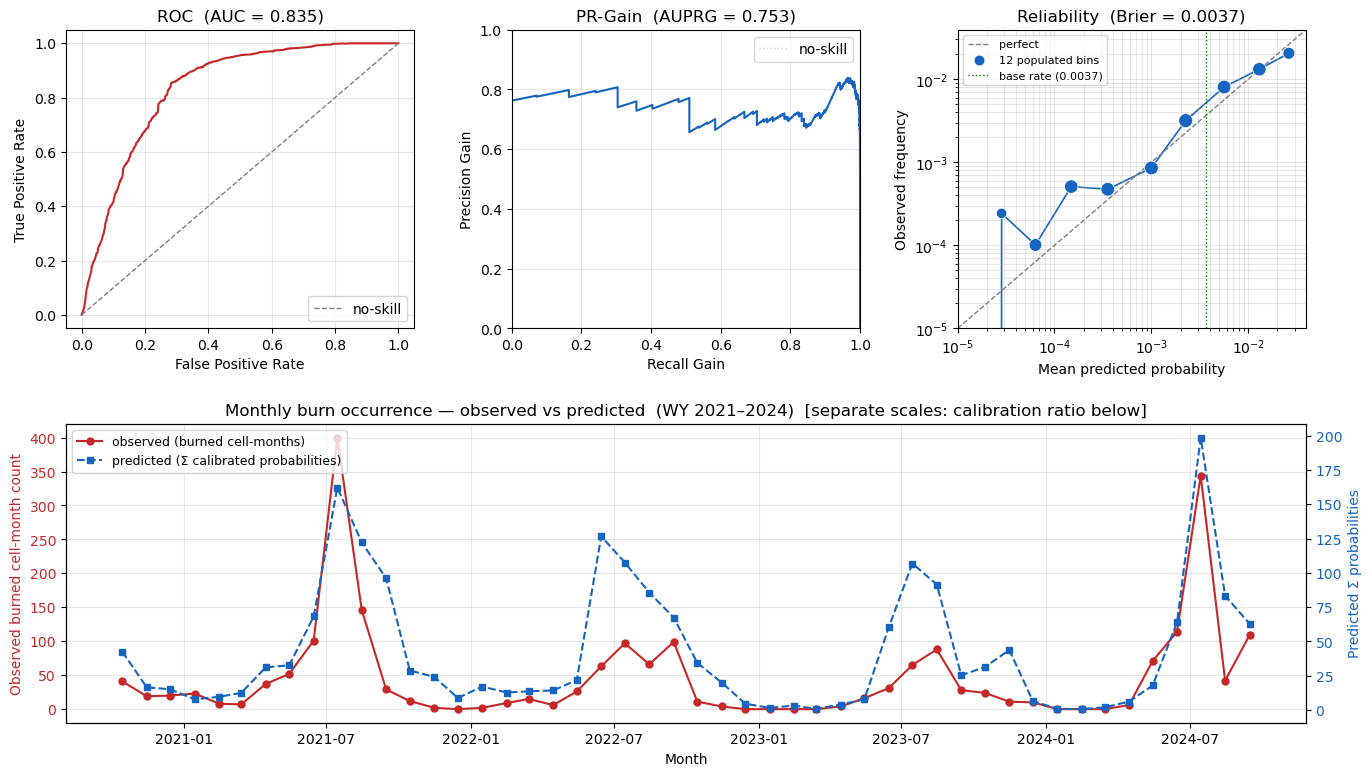

Reliability bins (log-spaced):
 bin_left  bin_right  n_cells  mean_pred  obs_freq
 0.000001   0.000002    25333   0.000002  0.000000
 0.000002   0.000006    20742   0.000004  0.000000
 0.000006   0.000015      290   0.000011  0.000000
 0.000015   0.000038     4128   0.000028  0.000242
 0.000038   0.000094    29687   0.000064  0.000101
 0.000094   0.000232    62824   0.000149  0.000509
 0.000232   0.000576    78276   0.000355  0.000473
 0.000576   0.001428    83168   0.001001  0.000854
 0.001428   0.003541   103849   0.002260  0.003168
 0.003541   0.008779    80146   0.005626  0.008035
 0.008779   0.021766    64309   0.013004  0.013155
 0.021766   0.053965    14397   0.026209  0.020490

Aggregate calibration (test 2021–2024):
  Observed   total burned cell-months : 2,258
  Predicted  total (Σ probabilities)  : 2,021.7
  Ratio (pred / obs)                   : 0.895
  Monthly Pearson  (obs vs pred)       : 0.835
  Monthly Spearman (obs vs pred)       : 0.869

AUPRG (pooled, 2021–2024): 0.

In [9]:
# ── 4.1  Diagnostics: ROC, PR-Gain, Reliability, monthly time series ─
# Reliability uses LOG-SPACED bin edges across the predicted-probability
# range (not quantile bins, which crowd into the bulk on heavy-tailed
# distributions). PR-Gain uses the Flach & Kull (2015) framework, which
# fixes the imbalance bias in the standard PR curve.

# Curves
fpr, tpr, _   = roc_curve(yt_all, yp_all)
prec, rec, _  = precision_recall_curve(yt_all, yp_all)
pi            = base_test
rg, pg        = precision_recall_gain(yt_all, yp_all)
auprg_val     = auprg(rg, pg)
mean_pred, frac_pos, n_bin, edges = log_reliability(
    yt_all, yp_all, n_bins=12, min_count=50)

# Monthly observed vs predicted (Σ calibrated probabilities)
ts = pred.groupby(["year", "month"]).agg(
    obs_count=("y_true", "sum"),
    pred_count=("y_prob", "sum"),
).reset_index()
ts["date"] = pd.to_datetime(ts[["year", "month"]].assign(day=15))
ts = ts.sort_values("date").reset_index(drop=True)


# Layout: ROC | PR-Gain | Reliability across the top, monthly TS spans bottom
fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.32, wspace=0.28)
ax_roc = fig.add_subplot(gs[0, 0])
ax_prg = fig.add_subplot(gs[0, 1])
ax_rel = fig.add_subplot(gs[0, 2])
ax_ts  = fig.add_subplot(gs[1, :])

# (a) ROC
ax_roc.plot(fpr, tpr, color="#C62828", lw=1.5)
ax_roc.plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="no-skill")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"ROC  (AUC = {roc:.3f})")
ax_roc.legend(loc="lower right"); ax_roc.grid(True, alpha=0.3)

# (b) PR-Gain (Flach & Kull 2015) — fixes the imbalance bias of standard PR
ax_prg.plot(rg, pg, color="#1565C0", lw=1.5)
ax_prg.plot([0, 1], [0, 0], ls=":", c="lightgrey", lw=1, label="no-skill")
ax_prg.set_xlim(0, 1); ax_prg.set_ylim(0, 1)
ax_prg.set_xlabel("Recall Gain"); ax_prg.set_ylabel("Precision Gain")
ax_prg.set_title(f"PR-Gain  (AUPRG = {auprg_val:.3f})")
ax_prg.legend(loc="upper right"); ax_prg.grid(True, alpha=0.3)

# (c) Reliability — log-log, log-spaced bins, point size ∝ log(bin count)
lo = max(min(mean_pred.min(), base_test) * 0.5, 1e-5)
hi = max(mean_pred.max(), base_test) * 1.5
ax_rel.plot([lo, hi], [lo, hi], ls="--", c="grey", lw=1, label="perfect")
if len(n_bin) > 0:
    rng = max(np.log10(n_bin.max()) - np.log10(n_bin.min()), 1e-9)
    sizes = 20 + 80 * (np.log10(n_bin) - np.log10(n_bin.min())) / rng
else:
    sizes = []
ax_rel.plot(mean_pred, frac_pos, "-", color="#1565C0", lw=1.2, zorder=1)
ax_rel.scatter(mean_pred, frac_pos, s=sizes, color="#1565C0", zorder=2,
               edgecolor="white", linewidth=0.5,
               label=f"{len(mean_pred)} populated bins")
ax_rel.axvline(base_test, ls=":", c="green", lw=1,
               label=f"base rate ({base_test:.4f})")
ax_rel.set_xscale("log"); ax_rel.set_yscale("log")
ax_rel.set_xlim(lo, hi); ax_rel.set_ylim(lo, hi)
ax_rel.set_xlabel("Mean predicted probability"); ax_rel.set_ylabel("Observed frequency")
ax_rel.set_title(f"Reliability  (Brier = {brier:.4f})")
ax_rel.legend(loc="upper left", fontsize=8); ax_rel.grid(True, alpha=0.3, which="both")

# (d) Monthly observed vs predicted — DUAL Y-AXES (very different scales).
#     Observed varies by ~2 orders of magnitude across the fire season;
#     predicted Σ-probabilities are nearly flat. Putting them on the same
#     y-axis squashes the predicted curve, so we give each its own axis.
ax_ts.plot(ts["date"], ts["obs_count"], "o-", color="#C62828",
           lw=1.5, ms=5, label="observed (burned cell-months)")
ax_ts.set_xlabel("Month")
ax_ts.set_ylabel("Observed burned cell-month count", color="#C62828")
ax_ts.tick_params(axis="y", labelcolor="#C62828")
ax_ts.grid(True, alpha=0.3)

ax_ts2 = ax_ts.twinx()
ax_ts2.plot(ts["date"], ts["pred_count"], "s--", color="#1565C0",
            lw=1.5, ms=5, label="predicted (Σ calibrated probabilities)")
ax_ts2.set_ylabel("Predicted Σ probabilities", color="#1565C0")
ax_ts2.tick_params(axis="y", labelcolor="#1565C0")

# Combine legends from both axes
lines1, labs1 = ax_ts.get_legend_handles_labels()
lines2, labs2 = ax_ts2.get_legend_handles_labels()
ax_ts.legend(lines1 + lines2, labs1 + labs2, loc="upper left", fontsize=9)
ax_ts.set_title(f"Monthly burn occurrence — observed vs predicted  "
                f"(WY {TEST_START_WY}–{TEST_END_WY})  "
                f"[separate scales: calibration ratio below]")

plt.savefig(os.path.join(MODEL_DIR, f"{RUN_TAG}_diagnostics.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Reliability bin table — explicit numbers, in case the plot is ambiguous
print("Reliability bins (log-spaced):")
_tbl = pd.DataFrame({
    "bin_left":  edges[:-1].round(6),
    "bin_right": edges[1:].round(6),
}).iloc[:len(n_bin)].assign(
    n_cells=n_bin, mean_pred=np.round(mean_pred, 6),
    obs_freq=np.round(frac_pos, 6))
print(_tbl.to_string(index=False))

# Aggregate calibration: total observed vs predicted across the 4 test years
print(f"\nAggregate calibration (test 2021–2024):")
print(f"  Observed   total burned cell-months : {int(ts['obs_count'].sum()):,}")
print(f"  Predicted  total (Σ probabilities)  : {ts['pred_count'].sum():,.1f}")
print(f"  Ratio (pred / obs)                   : "
      f"{ts['pred_count'].sum() / max(ts['obs_count'].sum(), 1):.3f}")
# Monthly co-movement: does the predicted curve track observed in SHAPE,
# independent of scale?  (Pearson + Spearman on the 48 monthly counts.)
from scipy.stats import pearsonr, spearmanr
_r_p, _ = pearsonr(ts["obs_count"], ts["pred_count"])
_r_s, _ = spearmanr(ts["obs_count"], ts["pred_count"])
print(f"  Monthly Pearson  (obs vs pred)       : {_r_p:.3f}")
print(f"  Monthly Spearman (obs vs pred)       : {_r_s:.3f}")
print(f"\nAUPRG (pooled, 2021–2024): {auprg_val:.4f}")

# Metrics comparison: autocontext → + rescale → (+ blend if BLEND_ALPHA > 0)
if "y_prob_orig" in pred.columns:
    yt_cmp = pred["y_true"].values
    yp_pre = pred["y_prob_orig"].values
    yp_resc= pred["y_prob_rescaled"].values if "y_prob_rescaled" in pred.columns else None
    yp_final = pred["y_prob"].values
    show_blend = (BLEND_ALPHA > 0 and yp_resc is not None
                  and not np.allclose(yp_resc, yp_final))
    show_resc  = yp_resc is not None and not np.allclose(yp_pre, yp_resc)

    def _aupg(yt, yp):
        rg_, pg_ = precision_recall_gain(yt, yp)
        return auprg(rg_, pg_)

    ts_obs = pred.groupby(["year","month"])["y_true"].sum()

    if show_blend:
        print(f"\nMetrics: autocontext  →  + rescale  →  + blend (α={BLEND_ALPHA:.2f})")
        for name, fn in [("PR-AUC",  lambda y: average_precision_score(yt_cmp, y)),
                         ("ROC-AUC", lambda y: roc_auc_score(yt_cmp, y)),
                         ("AUPRG",   lambda y: _aupg(yt_cmp, y)),
                         ("Brier",   lambda y: brier_score_loss(yt_cmp, y))]:
            v_pre, v_re, v_post = fn(yp_pre), fn(yp_resc), fn(yp_final)
            fmt = ".5f" if name == "Brier" else ".4f"
            print(f"  {name:<9}: {v_pre:{fmt}}  →  {v_re:{fmt}}  →  {v_post:{fmt}}")
        ts_pre  = pred.groupby(["year","month"])["y_prob_orig"].sum()
        ts_resc = pred.groupby(["year","month"])["y_prob_rescaled"].sum()
        ts_post = pred.groupby(["year","month"])["y_prob"].sum()
        print(f"  Monthly r : "
              f"{pearsonr(ts_obs, ts_pre)[0]:.3f}  →  "
              f"{pearsonr(ts_obs, ts_resc)[0]:.3f}  →  "
              f"{pearsonr(ts_obs, ts_post)[0]:.3f}")
    elif show_resc:
        print(f"\nMetrics: autocontext  →  + hierarchical rescale")
        print(f"  PR-AUC   : {average_precision_score(yt_cmp, yp_pre):.4f}  →  "
              f"{average_precision_score(yt_cmp, yp_final):.4f}")
        print(f"  ROC-AUC  : {roc_auc_score(yt_cmp, yp_pre):.4f}  →  "
              f"{roc_auc_score(yt_cmp, yp_final):.4f}")
        print(f"  AUPRG    : {_aupg(yt_cmp, yp_pre):.4f}  →  {_aupg(yt_cmp, yp_final):.4f}")
        print(f"  Brier    : {brier_score_loss(yt_cmp, yp_pre):.5f}  →  "
              f"{brier_score_loss(yt_cmp, yp_final):.5f}")
        ts_pre  = pred.groupby(["year","month"])["y_prob_orig"].sum()
        ts_post = pred.groupby(["year","month"])["y_prob"].sum()
        print(f"  Monthly Pearson (obs vs Σpred): "
              f"{pearsonr(ts_obs, ts_pre)[0]:.3f}  →  "
              f"{pearsonr(ts_obs, ts_post)[0]:.3f}")


---
## Stage 4b — Spatial diagnostics (within-month + per-ecoregion)

Pooled PR-AUC mixes two effects: (a) the model's ability to rank cells *within*
a given month and (b) its ability to rank *months* against each other. The
hierarchical rescale only changes (b) — within-month ranking is preserved by
the per-month logit shift — so a within-month breakdown isolates (a), the
purely *spatial* skill. The per-ecoregion breakdown then asks whether that
spatial skill is geographically concentrated (good in some regions, poor in
others).

In [10]:
# ── 4b.1  Within-month spatial skill ──────────────────────
# PR-AUC and lift computed PER MONTH, then aggregated. Drops months with too
# few fires to score (n_pos < MIN_FIRES). Because the hierarchical rescale is
# a within-month logit shift, the within-month PR-AUC is INVARIANT to the
# rescale and is therefore a clean measure of spatial discrimination.
#
# Interpretation:
#   - mean within-month PR-AUC ≈ pooled PR-AUC  → most pooled skill is from
#     within-month ranking (i.e. the model genuinely knows where fires go).
#   - mean within-month lift ≪ pooled lift      → most pooled skill is from
#     the rescale doing the cross-month work; cell model is spatially weak.

MIN_FIRES = 5

wm_rows = []
have_orig = "y_prob_orig" in pred.columns
for (yr, mo), g in pred.groupby(["year", "month"]):
    n_pos = int(g["y_true"].sum())
    if n_pos < MIN_FIRES:
        continue
    base = g["y_true"].mean()
    row = dict(
        year=yr, month=mo, n=len(g), n_pos=n_pos, base_pct=base * 100,
        pr_auc=average_precision_score(g["y_true"], g["y_prob"]),
        roc_auc=roc_auc_score(g["y_true"], g["y_prob"]),
    )
    row["lift"] = row["pr_auc"] / base
    if have_orig:
        row["pr_auc_orig"] = average_precision_score(g["y_true"], g["y_prob_orig"])
    wm_rows.append(row)

wm = pd.DataFrame(wm_rows).sort_values(["year", "month"]).reset_index(drop=True)

cols = ["year", "month", "n_pos", "base_pct", "pr_auc", "roc_auc", "lift"]
if have_orig:
    cols.insert(5, "pr_auc_orig")
print(f"Per-month spatial skill (months with ≥ {MIN_FIRES} fires):")
print(wm[cols].to_string(index=False, formatters={
    "base_pct": "{:.4f}".format, "pr_auc": "{:.4f}".format,
    "pr_auc_orig": "{:.4f}".format, "roc_auc": "{:.4f}".format,
    "lift": "{:.1f}".format}))

print(f"\nScored months           : {len(wm)} / {pred.groupby(['year','month']).ngroups}")
print(f"Mean within-month PR-AUC : {wm['pr_auc'].mean():.4f}")
print(f"Mean within-month ROC-AUC: {wm['roc_auc'].mean():.4f}")
print(f"Mean within-month lift   : {wm['lift'].mean():.2f}×")
print(f"Median within-month lift : {wm['lift'].median():.2f}×")
print(f"\nPooled (for comparison)  : PR-AUC {pr_auc:.4f}, ROC-AUC {roc:.4f}, "
      f"lift {pr_auc/base_test:.1f}×")

if have_orig:
    # Sanity check: rescale must preserve within-month ranking exactly.
    delta = (wm["pr_auc"] - wm["pr_auc_orig"]).abs().max()
    print(f"\nSanity check (rescale preserves within-month rank):")
    print(f"  max |PR-AUC − PR-AUC_orig| across months = {delta:.2e}  "
          f"({'OK' if delta < 1e-6 else 'WARNING: rescale changed within-month rank!'})")

# Persist for the manuscript
wm.to_csv(os.path.join(MODEL_DIR, f"{RUN_TAG}_within_month_skill.csv"), index=False)


Per-month spatial skill (months with ≥ 5 fires):
 year  month  n_pos base_pct pr_auc pr_auc_orig roc_auc lift
 2020     10     41   0.3229 0.0053      0.0053  0.6882  1.6
 2020     11     19   0.1496 0.0017      0.0017  0.4417  1.2
 2020     12     20   0.1575 0.0192      0.0192  0.9337 12.2
 2021      1     23   0.1811 0.0202      0.0202  0.8054 11.1
 2021      2      8   0.0630 0.0021      0.0021  0.7646  3.4
 2021      3      7   0.0551 0.0149      0.0149  0.5637 27.0
 2021      4     37   0.2914 0.0119      0.0119  0.6306  4.1
 2021      5     52   0.4095 0.0144      0.0144  0.8252  3.5
 2021      6    101   0.7953 0.0143      0.0143  0.6853  1.8
 2021      7    400   3.1499 0.0242      0.0242  0.3897  0.8
 2021      8    146   1.1497 0.0136      0.0136  0.5711  1.2
 2021      9     29   0.2284 0.0051      0.0051  0.7285  2.2
 2021     10     12   0.0945 0.0011      0.0011  0.4690  1.1
 2022      2      9   0.0709 0.0047      0.0047  0.5907  6.6
 2022      3     15   0.1181 0.0016 

In [11]:
# ── 4b.2  Per-ecoregion spatial skill ────────────────────
# Pooled PR-AUC and lift broken out by EPA Level III ecoregion. Identifies
# whether spatial skill is geographically concentrated. A small lift in a
# fire-prone region (e.g. Sierra Nevada, Southern California Mountains) is a
# real skill gap; small lift in a region with almost no fires (e.g. Mojave)
# is unsurprising and not interpretable.
#
# Requires `ecoregion` column to be present on `pred`. If it isn't, the
# ecoregion is recovered from `ids`.

if "ecoregion" not in pred.columns:
    # Recover from ids (we kept lon/lat/year/month but dropped ecoregion).
    # Cheapest way: re-load just the lookup columns from the source parquet.
    eco_lookup = pd.read_parquet(DATA_PATH, columns=["lon", "lat", "year", "month", "ecoregion"])
    pred = pred.merge(eco_lookup, on=["lon", "lat", "year", "month"], how="left")
    del eco_lookup; gc.collect()

eco_rows = []
for eco, g in pred.groupby("ecoregion"):
    n_pos = int(g["y_true"].sum())
    if n_pos < 5:
        eco_rows.append(dict(ecoregion=eco, n=len(g), n_pos=n_pos,
                             base_pct=g["y_true"].mean()*100,
                             pr_auc=np.nan, roc_auc=np.nan, lift=np.nan))
        continue
    base = g["y_true"].mean()
    eco_rows.append(dict(
        ecoregion=eco, n=len(g), n_pos=n_pos, base_pct=base*100,
        pr_auc=average_precision_score(g["y_true"], g["y_prob"]),
        roc_auc=roc_auc_score(g["y_true"], g["y_prob"]),
        lift=average_precision_score(g["y_true"], g["y_prob"]) / base,
    ))
eco_df = pd.DataFrame(eco_rows).sort_values("n_pos", ascending=False).reset_index(drop=True)

print("Per-ecoregion skill (pooled across 2021–2024):")
print(eco_df.to_string(index=False, formatters={
    "base_pct": "{:.4f}".format, "pr_auc": "{:.4f}".format,
    "roc_auc": "{:.4f}".format, "lift": "{:.2f}".format}))

eco_df.to_csv(os.path.join(MODEL_DIR, f"{RUN_TAG}_ecoregion_skill.csv"), index=False)


Per-ecoregion skill (pooled across 2021–2024):
                                          ecoregion      n  n_pos base_pct pr_auc roc_auc  lift
 Central California Foothills and Coastal Mountains 155952    636   0.4078 0.0165  0.8193  4.05
                                      Sierra Nevada 119616    493   0.4122 0.0160  0.8450  3.89
                      Southern California Mountains  40080    210   0.5240 0.0165  0.8107  3.15
            Southern California/Northern Baja Coast  33408    206   0.6166 0.0117  0.7314  1.90
                                           Cascades  38400    203   0.5286 0.0414  0.8995  7.83
Klamath Mountains/California High North Coast Range  73248    188   0.2567 0.0100  0.8577  3.90
                          Central California Valley  22560    183   0.8112 0.0264  0.8089  3.26
              Eastern Cascades Slopes and Foothills  40992     42   0.1025 0.0052  0.7354  5.08
                            Central Basin and Range  25584     40   0.1563 0.0223  0.6591

---
## Stage 5 — Save outputs & summary

In [ ]:
# ── 5.1  Persist the calibrated probability surface + metrics ─
pred_path = os.path.join(MODEL_DIR, f"{RUN_TAG}_2021_2024_probabilities.parquet")
year_path = os.path.join(MODEL_DIR, f"{RUN_TAG}_year_metrics.csv")
ts_path   = os.path.join(MODEL_DIR, f"{RUN_TAG}_monthly_timeseries.csv")
feat_path = os.path.join(MODEL_DIR, f"{RUN_TAG}_features.csv")
mreg_path = os.path.join(MODEL_DIR, f"{RUN_TAG}_monthly_poisson_pred.csv")

pred.to_parquet(pred_path, index=False)
year_df.to_csv(year_path, index=False)
ts[["date", "year", "month", "obs_count", "pred_count"]].to_csv(ts_path, index=False)
pd.DataFrame({"feature": feature_cols_ac}).to_csv(feat_path, index=False)
if HIERARCHICAL_RESCALE:
    mte_data[["year","month","obs_count","pred_count"] +
             monthly_feat].to_csv(mreg_path, index=False)

print("Saved:")
paths = [pred_path, year_path, ts_path, feat_path]
if HIERARCHICAL_RESCALE: paths.append(mreg_path)
for p in paths:
    print(f"  {p}")

print(f"\n=== OCCURRENCE MODEL SUMMARY ({RUN_TAG}) ===")
print(f"  Train WY        : {TRAIN_START_WY}–{TRAIN_END_WY}")
print(f"  Test WY         : {TEST_START_WY}–{TEST_END_WY}")
print(f"  Features        : {len(feature_cols_ac)}  (incl. nbr_pred_mean3, nbr_pred_p90 auto-context)")
print(f"  Test base rate  : {base_test*100:.4f}%")
print(f"  Pooled PR-AUC   : {pr_auc:.4f}  (lift {pr_auc/base_test:.1f}x)")
print(f"  Pooled ROC-AUC  : {roc:.4f}")
print(f"  Pooled Brier    : {brier:.5f}")
print(f"  Pooled AUPRG    : {auprg_val:.4f}")
print(f"  Class weighting : {USE_CLASS_WEIGHT}")
print(f"  Output          : calibrated burn probability (no threshold applied)")
